<a href="https://colab.research.google.com/github/esdrasantos/statistical-concepts-and-practice/blob/main/cstfm_mod_11_regressao_simples_heteroscedasticidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
file_path = '/content/drive/MyDrive/Curso de Estatística 2.0/Arquivos Excel/Dados4_CursoEstatistica.xlsx'

df = pd.read_excel(file_path)
display(df.head())

,preco,m2
0,840000,257
1,822000,232
2,713000,222
3,689000,204
4,685000,252


In [38]:
df.describe().round(4)

,preco,m2
count,36.0000,36.0000
mean,507502.7778,173.9167
std,136396.3185,55.0223
min,307500.0000,78.0000
25%,394250.0000,131.0000
50%,502500.0000,161.0000
75%,585625.0000,213.7500
max,840000.0000,303.0000


<Axes: xlabel='preco'>

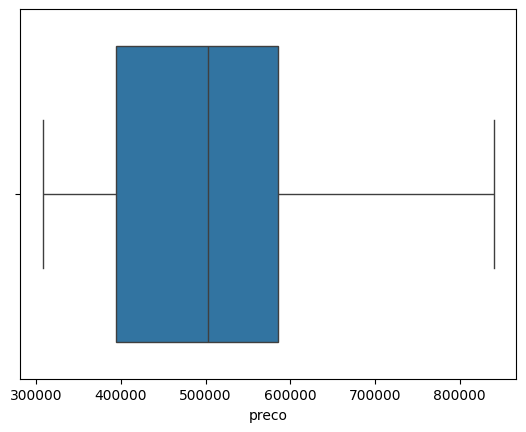

In [39]:
sns.boxplot(df['preco'], orient='h', )


<Axes: xlabel='m2'>

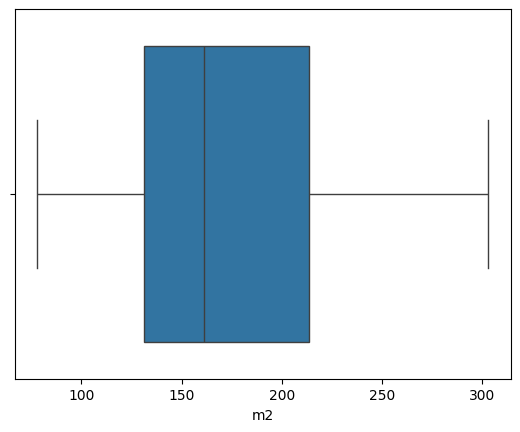

In [40]:
sns.boxplot(df['m2'], orient='h', )

Text(0, 0.5, 'Preço')

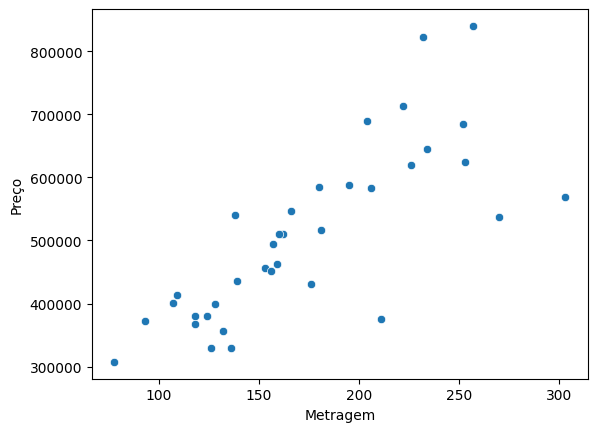

In [41]:
sns.scatterplot(x=df['m2'], y=df['preco'])
plt.xlabel('Metragem')
plt.ylabel('Preço')

In [42]:
# Força intercepto a 0. y = ax
X = sm.add_constant(df['m2']) # Adicionando intercepto
y = df['preco']

# Modelo é o método dos mínimos quadrados
modelo = sm.OLS(y, X).fit()
modelo.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  preco   R-squared:                       0.603
Model:                            OLS   Adj. R-squared:                  0.591
Method:                 Least Squares   F-statistic:                     51.66
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           2.59e-08
Time:                        04:43:59   Log-Likelihood:                -459.58
No. Observations:                  36   AIC:                             923.2
Df Residuals:                      34   BIC:                             926.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.727e+05   4.88e+04      3.539      0.001    7.35e+04    2.72e+05
m2          1925.1299    267.833      7.188      0.000    1380.829    2469.431
==============================================================================
Omnibus:                        1.842   Durbin-Watson:                   1.301
Prob(Omnibus):                  0.398   Jarque-Bera (JB):                0.834
Skew:                          -0.134   Prob(JB):                        0.659
Kurtosis:                       3.696   Cond. No.                         612.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
residuos = modelo.resid
residuos.head()

,0
0,172551.012810
1,202679.260376
2,112930.559403
3,123582.897651
4,27176.662323


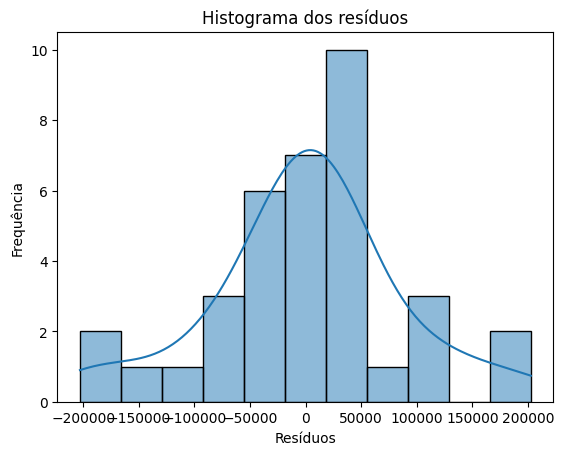

In [44]:
sns.histplot(residuos, kde=True)
plt.xlabel('Resíduos')
plt.ylabel('Frequência')
plt.title('Histograma dos resíduos')

plt.show()

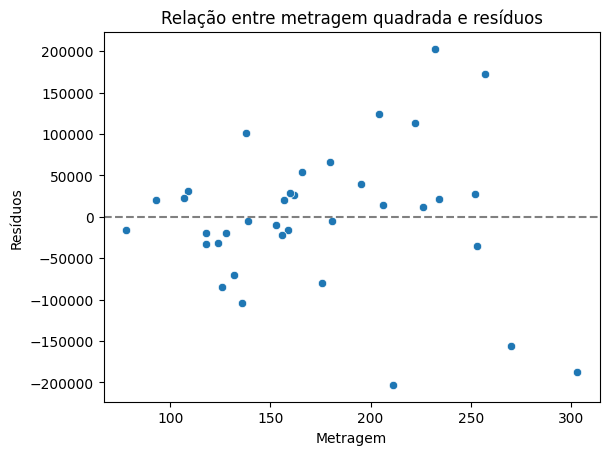

In [45]:
sns.scatterplot(x=df['m2'], y=residuos)
plt.axhline(y=0, color='gray', linestyle='--')
plt.xlabel('Metragem')
plt.ylabel('Resíduos')
plt.title('Relação entre metragem quadrada e resíduos')

plt.show()

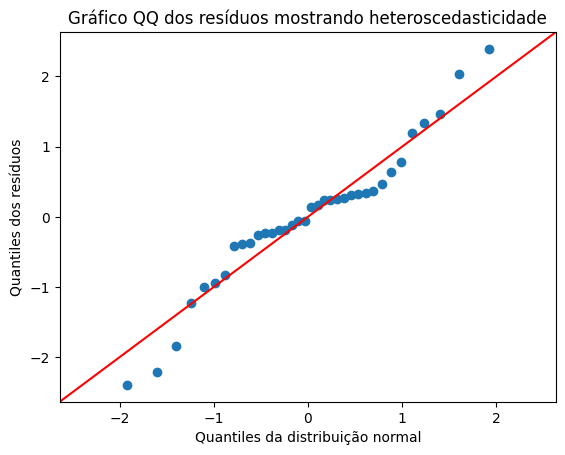

In [46]:
sm.qqplot(residuos, line='45', fit=True)
plt.xlabel('Quantiles da distribuição normal')
plt.ylabel('Quantiles dos resíduos')
plt.title('Gráfico QQ dos resíduos mostrando heteroscedasticidade')

plt.show()

Text(0.5, 1.0, 'Relação entre Preço por metro quadrado e metragem quadrada')

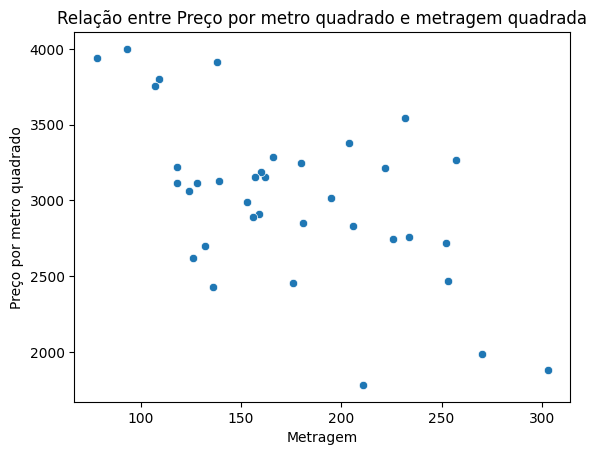

In [47]:
sns.scatterplot(x=df['m2'], y=df['preco']/df['m2'])
plt.xlabel('Metragem')
plt.ylabel('Preço por metro quadrado')
plt.title('Relação entre Preço por metro quadrado e metragem quadrada')

In [48]:
# Regresseão com tranformação fracionária

X = sm.add_constant(df['m2']) # Adicionando intercepto
y = df['preco']/df['m2']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.322
Method:                 Least Squares   F-statistic:                     17.62
Date:                Tue, 17 Feb 2026   Prob (F-statistic):           0.000183
Time:                        04:44:00   Log-Likelihood:                -269.16
No. Observations:                  36   AIC:                             542.3
Df Residuals:                      34   BIC:                             545.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4000.2822    246.110     16.254      0.0

In [49]:
residuos = modelo.resid

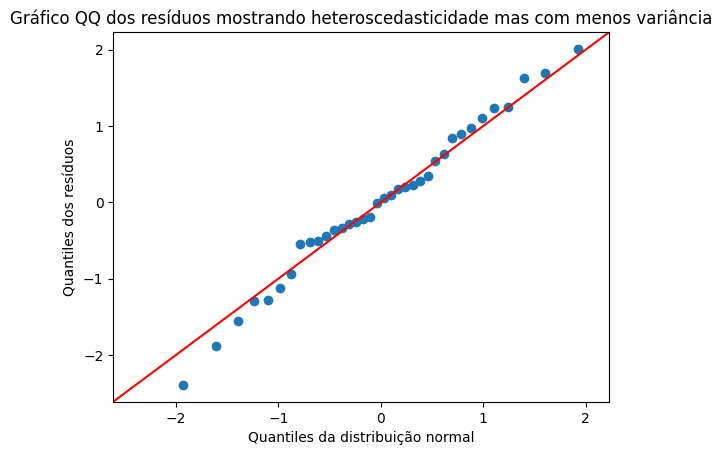

In [50]:
sm.qqplot(residuos, line='45', fit=True)
plt.xlabel('Quantiles da distribuição normal')
plt.ylabel('Quantiles dos resíduos')
plt.title('Gráfico QQ dos resíduos mostrando heteroscedasticidade mas com menos variância')

plt.show()

In [51]:
intervalo_confianca = modelo.conf_int(alpha=0.10)
print(intervalo_confianca)

                 0            1
const  3584.128392  4416.436087
m2       -7.954984    -3.386439


In [59]:
novo_valor = 200
novo_X = pd.DataFrame({'m2':[novo_valor]})
novo_X = sm.add_constant(novo_X, has_constant='add')

novo_preco_por_m2_previsto = modelo.predict(novo_X)
preco_total_previsto = novo_preco_por_m2_previsto * novo_valor

print(f'Previsao para um imovel de {novo_valor} m2:')
print(f'Preço por m2 previsto: {novo_preco_por_m2_previsto[0]:.2f}')
print(f'Preço total previso: R$ {preco_total_previsto[0]:.2f}')

Previsao para um imovel de 200 m2:
Preço por m2 previsto: 2866.14
Preço total previso: R$ 573227.97
